# 05 - Results Summary and Figure Regeneration

## 1. Notebook Goal
Aggregate all saved Phase 2 artifacts into final tables and figures without rerunning inference.

## 2. Experimental Design
- Load evaluation, imbalance, and continual-learning JSON outputs.
- Prefer no-alpha evaluation results when that artifact exists.
- Regenerate publication figures with consistent styling.
- Build a consolidated final CSV for reporting and comparisons.
- Print final overall and per-class summaries for quick review.

## 3. Inputs
- results/phase2/evaluation_results.json or evaluation_no_alpha_results.json
- results/phase2/imbalance_results.json
- results/phase2/continual_learning_results.json

## 4. Outputs
- figures/phase2/ regenerated summary plots
- results/phase2/final_results_summary.csv
- notebook-printed summary tables

## 5. Execution Guide
Run the notebook in order after upstream experiments are complete to refresh final report artifacts.

### Cell 2 - Imports, Paths, and Figure Directory Setup
Purpose: import required helpers, resolve result-file paths, choose tuned vs no-alpha evaluation source, and ensure output directories exist.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from cycler import cycler

sys.path.insert(0, str(Path("../..").resolve()))

from src.phase2.config import get_phase2_config
from src.phase2.evaluation import load_results
from src.phase2.visualization import (
    plot_alpha_sensitivity,
    plot_confusion_matrices,
    plot_continual_learning_curve,
    plot_minority_f1_vs_imbalance,
    plot_phase2_vs_phase1,
    plot_scoring_comparison,
)

CONFIG = get_phase2_config()

REPO_ROOT = Path("../..").resolve()
EVAL_PATH_DEFAULT = REPO_ROOT / "results" / "phase2" / "evaluation_results.json"
EVAL_PATH_NO_ALPHA = REPO_ROOT / "results" / "phase2" / "evaluation_no_alpha_results.json"
EVAL_PATHS = {
    "tuned": EVAL_PATH_DEFAULT,
    "no_alpha": EVAL_PATH_NO_ALPHA,
}

# Reporting mode options: "auto", "tuned", "no_alpha", or "both"
EVAL_MODE = "auto"

if EVAL_MODE not in {"auto", "tuned", "no_alpha", "both"}:
    raise ValueError(
        f"Unsupported EVAL_MODE={EVAL_MODE!r}. Expected one of: auto, tuned, no_alpha, both."
    )

if EVAL_MODE == "auto":
    if EVAL_PATH_NO_ALPHA.exists():
        selected_eval_keys = ["no_alpha"]
    elif EVAL_PATH_DEFAULT.exists():
        selected_eval_keys = ["tuned"]
    else:
        raise FileNotFoundError(
            "Missing evaluation results. Expected evaluation_results.json or evaluation_no_alpha_results.json."
        )
elif EVAL_MODE == "both":
    selected_eval_keys = [key for key, path in EVAL_PATHS.items() if path.exists()]
    if not selected_eval_keys:
        raise FileNotFoundError(
            "EVAL_MODE='both' requested, but neither tuned nor no-alpha evaluation file was found."
        )
else:
    selected_eval_keys = [EVAL_MODE]
    if not EVAL_PATHS[EVAL_MODE].exists():
        raise FileNotFoundError(
            f"Requested EVAL_MODE='{EVAL_MODE}', but file was not found: {EVAL_PATHS[EVAL_MODE]}"
        )

selected_eval_paths = {key: EVAL_PATHS[key] for key in selected_eval_keys}
PRIMARY_EVAL_KEY = "no_alpha" if "no_alpha" in selected_eval_paths else selected_eval_keys[0]
PRIMARY_EVAL_PATH = selected_eval_paths[PRIMARY_EVAL_KEY]

IMB_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_results.json"
CONT_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning_results.json"
FIG_DIR = REPO_ROOT / "figures" / "phase2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not IMB_PATH.exists():
    raise FileNotFoundError(f"Missing imbalance results file: {IMB_PATH}")
if not CONT_PATH.exists():
    raise FileNotFoundError(f"Missing continual-learning results file: {CONT_PATH}")

print(f"Evaluation mode: {EVAL_MODE}")
print(f"Primary evaluation payload: {PRIMARY_EVAL_KEY} -> {PRIMARY_EVAL_PATH.name}")
print("Loaded evaluation payload candidates:")
for key, path in selected_eval_paths.items():
    print(f"  - {key}: {path.name}")

Evaluation mode: auto
Primary evaluation payload: no_alpha -> evaluation_no_alpha_results.json
Loaded evaluation payload candidates:
  - no_alpha: evaluation_no_alpha_results.json


### Cell 3 - Load Saved Experiment Outputs
Purpose: read persisted JSON artifacts for evaluation, imbalance, and continual-learning so all subsequent reporting is reproducible and file-driven.

In [7]:
evaluation_payloads = {
    key: load_results(str(path)) for key, path in selected_eval_paths.items()
}
evaluation_results = evaluation_payloads[PRIMARY_EVAL_KEY]
imbalance_results = load_results(str(IMB_PATH))
continual_results = load_results(str(CONT_PATH))

print(f"Primary payload selected for reporting: {PRIMARY_EVAL_KEY}")
print(f"Primary variants available: {list(evaluation_results.get('variants', {}).keys())}")
if len(evaluation_payloads) > 1:
    print("Multi-mode comparison enabled for tuned vs fixed-alpha reporting.")

Primary payload selected for reporting: no_alpha
Primary variants available: ['majority_vote', 'idw', 'global_dnds', 'local_dnds', 'kde_dnds', 'traditional']


### Cell 4 - Build and Save Consolidated Final CSV
Purpose: compute cross-experiment comparison fields (including alpha settings and imbalance gains) and export a single summary CSV for reporting.

In [8]:
import csv

SUMMARY_CSV_PATH = REPO_ROOT / "results" / "phase2" / "final_results_summary.csv"
SUMMARY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

available_ratios = [str(r) for r in imbalance_results.get("ratios", [])]
if "10" in available_ratios:
    ratio_key = "10"
elif available_ratios:
    ratio_key = max(available_ratios, key=lambda x: int(x))
else:
    ratio_key = None

local_ttr = (
    imbalance_results.get("variants", {})
    .get("local_dnds", {})
    .get(ratio_key, {})
    .get("per_class_f1", {})
    .get("TTR", 0.0)
    if ratio_key is not None
    else 0.0
)
other_ttr = (
    [
        metrics.get(ratio_key, {}).get("per_class_f1", {}).get("TTR", 0.0)
        for name, metrics in imbalance_results.get("variants", {}).items()
        if name != "local_dnds"
    ]
    if ratio_key is not None
    else []
)
best_other_ttr = max(other_ttr) if other_ttr else 0.0
gain = local_ttr - best_other_ttr

alpha_tuning_enabled = evaluation_results.get("alpha_tuning", {}).get("enabled", True)
best_alpha_local = evaluation_results.get(
    "best_alpha_local", evaluation_results.get("best_alpha", "n/a")
)
best_alpha_kde = evaluation_results.get(
    "best_alpha_kde", evaluation_results.get("best_alpha", "n/a")
)
alpha_setting = (
    f"tuned(local={best_alpha_local},kde={best_alpha_kde})"
    if alpha_tuning_enabled
    else f"fixed(local={best_alpha_local},kde={best_alpha_kde})"
)

rac_variants = [
    name for name in evaluation_results["variants"].keys() if name != "traditional"
]
best_variant_name = (
    max(
        rac_variants,
        key=lambda name: evaluation_results["variants"][name].get("macro_f1", 0.0),
    )
    if rac_variants
    else None
)

rows = []
for name, metrics in evaluation_results["variants"].items():
    rows.append(
        {
            "variant": name,
            "accuracy": metrics.get("accuracy", 0.0),
            "macro_f1": metrics.get("macro_f1", 0.0),
            "weighted_f1": metrics.get("weighted_f1", 0.0),
            "ttr_f1": metrics.get("per_class_f1", {}).get("TTR", 0.0),
            "inference_time_ms": metrics.get(
                "inference_time_ms", metrics.get("latency_ms_per_sample", 0.0)
            ),
            "alpha_setting": alpha_setting,
            "imbalance_ratio_key": ratio_key if ratio_key is not None else "n/a",
            "ttr_gain_selected_ratio_to_best_other": gain,
            "is_best_rac": int(name == best_variant_name),
        }
    )

headers = [
    "variant",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "ttr_f1",
    "inference_time_ms",
    "alpha_setting",
    "imbalance_ratio_key",
    "ttr_gain_selected_ratio_to_best_other",
    "is_best_rac",
]

with SUMMARY_CSV_PATH.open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=headers)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved consolidated final CSV: {SUMMARY_CSV_PATH}")

Saved consolidated final CSV: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\final_results_summary.csv


### Cell 5 - Regenerate Final Figures with Consistent Styling
Purpose: apply plotting style preferences and regenerate all summary figures (scoring, alpha sensitivity, confusion matrices, imbalance, and continual-learning).

Alpha sweep data not found; skipping alpha sensitivity figure.


D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=macro_f1, ax=ax, palette=bar_colors)
D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=["#6c757d", "#2a9d8f"], ax=ax)


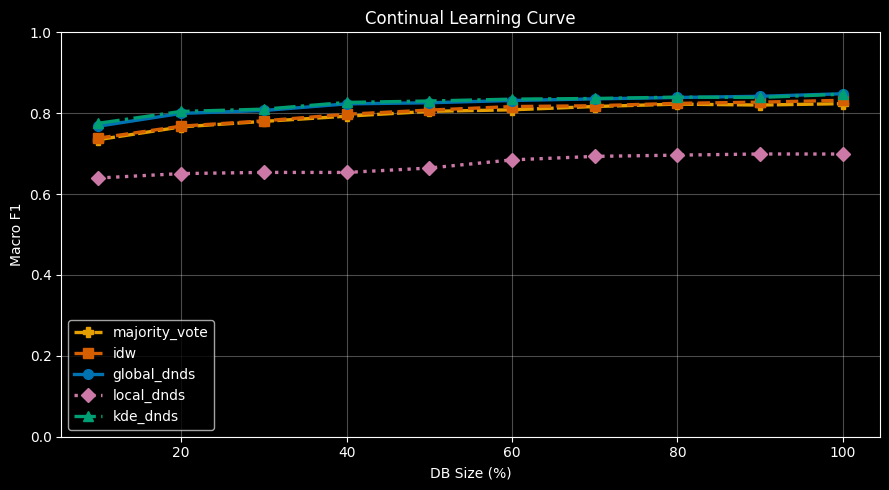

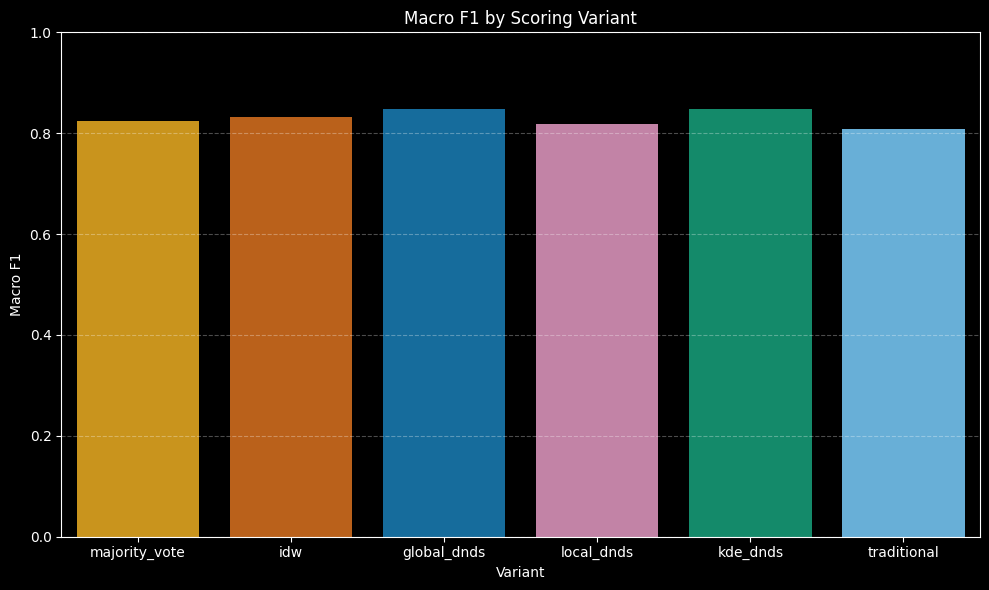

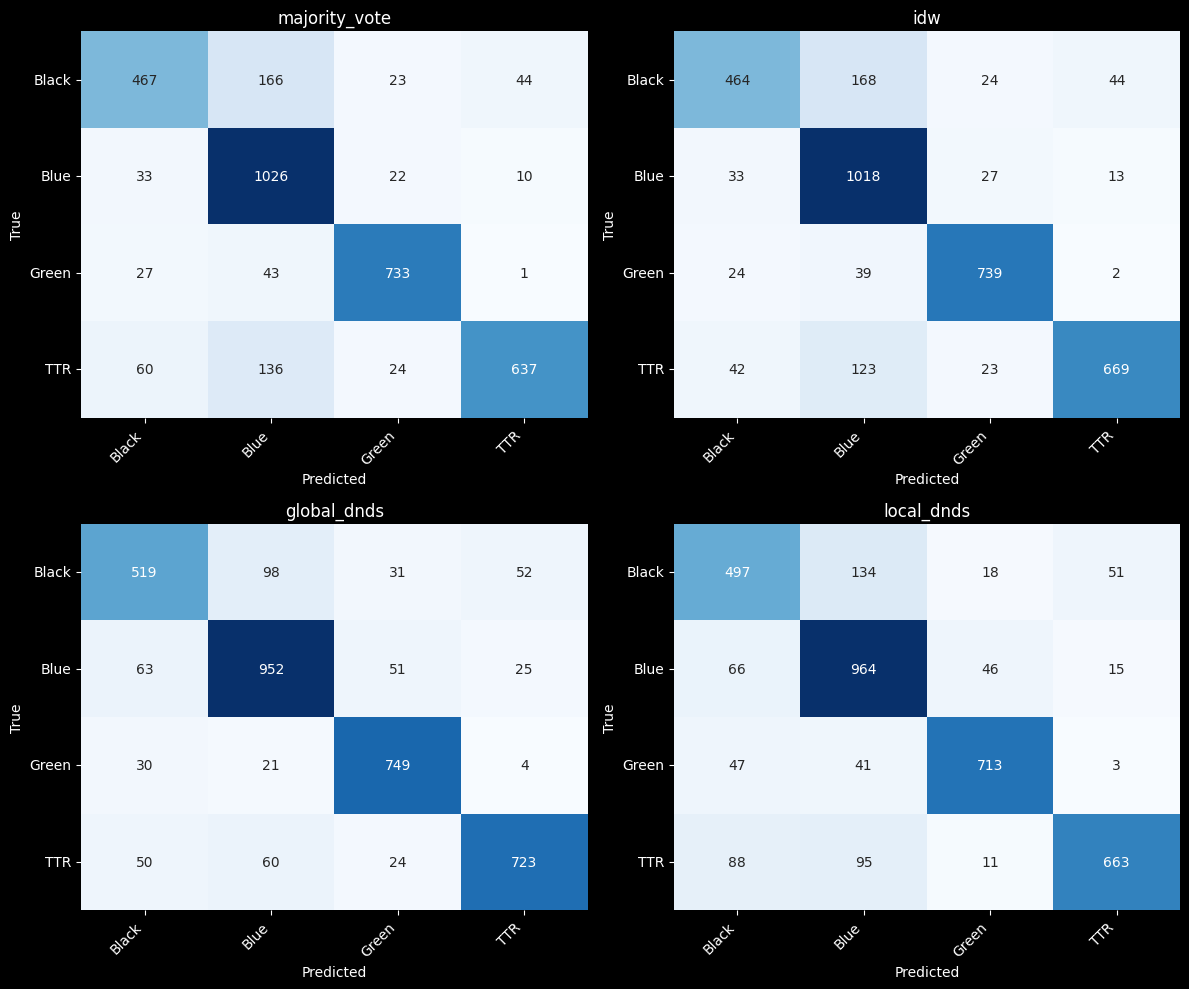

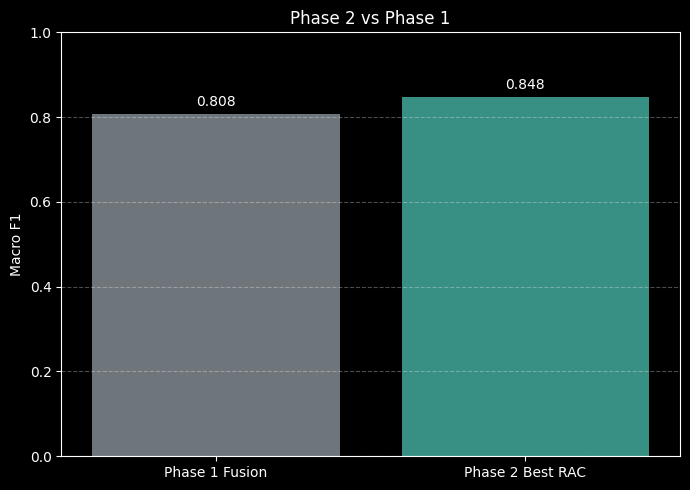

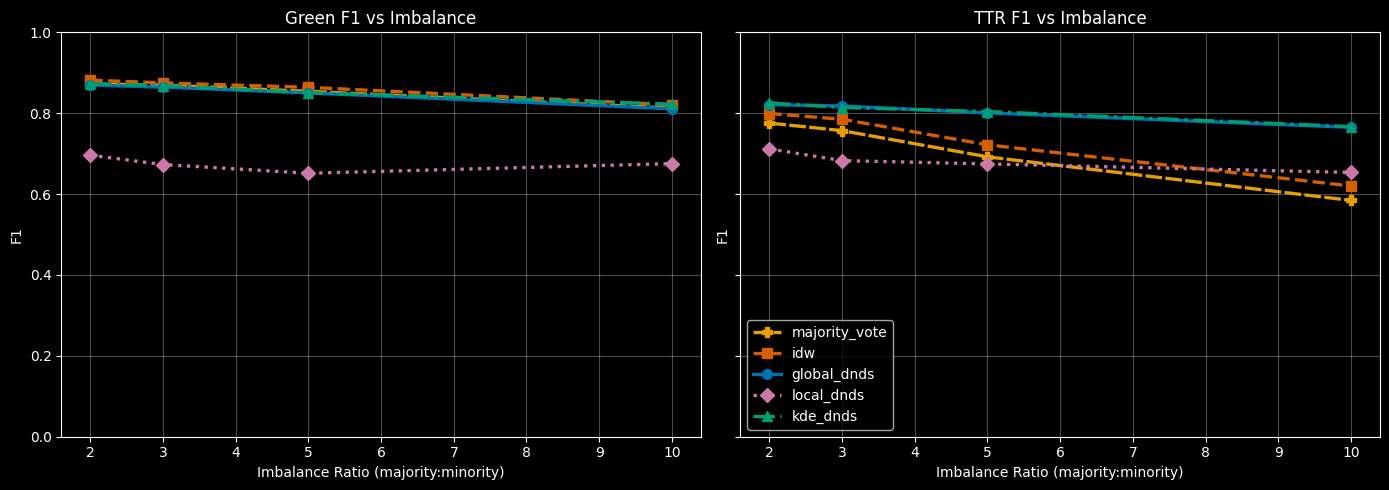

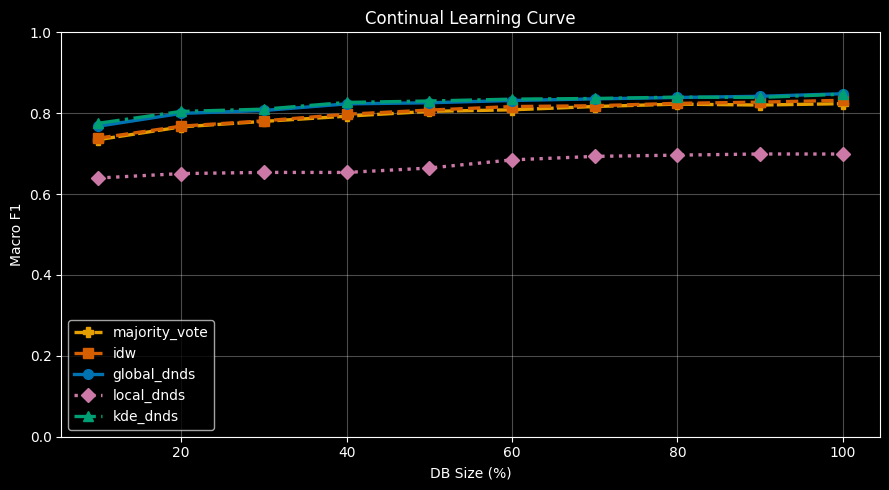

In [9]:
# Match the visual style used in 03_imbalance_experiment.ipynb
variant_palette = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#E69F00",
    "#56B4E9",
    "#000000",
    "#F0E442",
]
variant_markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
variant_linestyles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (5, 1)),
    (0, (3, 1, 1, 1)),
    (0, (1, 1)),
    (0, (3, 5, 1, 5)),
]
plt.rcParams["axes.prop_cycle"] = (
    cycler(color=variant_palette)
    + cycler(marker=variant_markers)
    + cycler(linestyle=variant_linestyles)
)
plt.rcParams["lines.linewidth"] = 2.4
plt.rcParams["lines.markersize"] = 7
plt.rcParams["grid.alpha"] = 0.35

plot_scoring_comparison(evaluation_results, str(FIG_DIR / "scoring_comparison.png"))

alpha_sweep = evaluation_results.get("alpha_sweep")
has_alpha_sweep = bool(alpha_sweep) and any(
    len(series.get("alphas", [])) > 0 for series in alpha_sweep.values()
)
if has_alpha_sweep:
    plot_alpha_sensitivity(
        evaluation_results["alpha_sweep"], str(FIG_DIR / "alpha_sensitivity.png")
    )
else:
    print("Alpha sweep data not found; skipping alpha sensitivity figure.")

plot_confusion_matrices(
    evaluation_results,
    CONFIG["class_names"],
    str(FIG_DIR / "confusion_matrices_phase2.png"),
)
phase1_macro_f1 = evaluation_results["variants"].get("traditional", {}).get(
    "macro_f1", 0.8177
)
rac_scores = [
    v.get("macro_f1", 0.0)
    for k, v in evaluation_results["variants"].items()
    if k != "traditional"
]
best_phase2 = max(rac_scores) if rac_scores else 0.0
plot_phase2_vs_phase1(
    best_phase2,
    phase1_macro_f1,
    str(FIG_DIR / "phase2_vs_phase1.png"),
)
plot_minority_f1_vs_imbalance(
    imbalance_results, str(FIG_DIR / "minority_f1_vs_imbalance.png")
)
plot_continual_learning_curve(
    continual_results, str(FIG_DIR / "continual_learning_curve.png")
)

### Cell 6 - Print Human-Readable Final Tables
Purpose: display overall and per-class metric tables, alpha configuration details, and key comparison statements for direct interpretation in the notebook output.

In [10]:
import pandas as pd

alpha_tuning_enabled = evaluation_results.get("alpha_tuning", {}).get("enabled", True)
best_alpha_local = evaluation_results.get(
    "best_alpha_local", evaluation_results.get("best_alpha", "n/a")
)
best_alpha_kde = evaluation_results.get(
    "best_alpha_kde", evaluation_results.get("best_alpha", "n/a")
)

print("=" * 60)
if alpha_tuning_enabled:
    print("PHASE 2 RAC EXPERIMENT (WITH ALPHA TUNING) - RESULTS SUMMARY")
else:
    print("PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - RESULTS SUMMARY")
print("=" * 60)
print("Variant              | Accuracy | Macro F1 | TTR F1 | Latency")
print("---------------------|----------|----------|--------|--------")
for name, metrics in evaluation_results["variants"].items():
    ttr_f1 = metrics.get("per_class_f1", {}).get("TTR", 0.0)
    latency = metrics.get(
        "inference_time_ms", metrics.get("latency_ms_per_sample", 0.0)
    )
    print(
        f"{name:<20} | {metrics['accuracy']*100:6.2f}% | {metrics['macro_f1']:.4f} | {ttr_f1:.4f} | {latency:.2f} ms"
    )
print("=" * 60)
if alpha_tuning_enabled:
    print(f"Best alpha (local DNDS): {best_alpha_local}")
    print(f"Best alpha (KDE-DNDS): {best_alpha_kde}")
else:
    print(
        f"Alpha tuning disabled (fixed local={best_alpha_local}, kde={best_alpha_kde})"
    )

available_ratios = [str(r) for r in imbalance_results.get("ratios", [])]
if "10" in available_ratios:
    ratio_key = "10"
elif available_ratios:
    ratio_key = max(available_ratios, key=lambda x: int(x))
else:
    ratio_key = None

local_ttr = (
    imbalance_results.get("variants", {})
    .get("local_dnds", {})
    .get(ratio_key, {})
    .get("per_class_f1", {})
    .get("TTR", 0.0)
    if ratio_key is not None
    else 0.0
)
other_ttr = (
    [
        metrics.get(ratio_key, {}).get("per_class_f1", {}).get("TTR", 0.0)
        for name, metrics in imbalance_results.get("variants", {}).items()
        if name != "local_dnds"
    ]
    if ratio_key is not None
    else []
)
best_other_ttr = max(other_ttr) if other_ttr else 0.0
gain = local_ttr - best_other_ttr
if ratio_key is None:
    print("Imbalance ratio data unavailable; skipping ratio-specific gain interpretation.")
else:
    print(f"Best imbalance correction gain on TTR F1 at {ratio_key}:1 ratio: {gain:+.3f}")

traditional_metrics = evaluation_results["variants"].get("traditional", {})
phase1_fused_per_class = traditional_metrics.get(
    "per_class_f1",
    {
        "Black": 0.7141,
        "Blue": 0.8220,
        "Green": 0.9171,
        "TTR": 0.8177,
    },
)

rac_variants = [
    name for name in evaluation_results["variants"].keys() if name != "traditional"
]
best_variant_name = (
    max(
        rac_variants,
        key=lambda name: evaluation_results["variants"][name].get("macro_f1", 0.0),
    )
    if rac_variants
    else "n/a"
)


def _build_wide_per_class_table(metric_key: str) -> pd.DataFrame:
    rows = []
    for cls in ["Black", "Blue", "Green", "TTR"]:
        row = {
            "Class": cls,
            "Phase 1 Fused": phase1_fused_per_class.get(cls, 0.0),
        }
        for variant_name in rac_variants:
            row[variant_name] = (
                evaluation_results["variants"][variant_name]
                .get(metric_key, {})
                .get(cls, 0.0)
            )
        rows.append(row)
    table = pd.DataFrame(rows)
    value_cols = [c for c in table.columns if c != "Class"]
    table[value_cols] = table[value_cols].apply(
        lambda col: col.map(lambda x: f"{x:.4f}")
    )
    return table


print("")
print("Per-Class F1 Table (All RAC Variants)")
f1_table = _build_wide_per_class_table("per_class_f1")
print(f1_table)

print("")
print("Per-Class Precision Table (All RAC Variants)")
precision_table = _build_wide_per_class_table("per_class_precision")
print(precision_table)

print("")
print("Per-Class Recall Table (All RAC Variants)")
recall_table = _build_wide_per_class_table("per_class_recall")
print(recall_table)

print("")
if best_variant_name == "n/a":
    print("Best RAC variant in this run (by Macro F1): n/a")
else:
    print(f"Best RAC variant in this run (by Macro F1): {best_variant_name}")

PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - RESULTS SUMMARY
Variant              | Accuracy | Macro F1 | TTR F1 | Latency
---------------------|----------|----------|--------|--------
majority_vote        |  82.94% | 0.8236 | 0.8225 | 125.34 ms
idw                  |  83.72% | 0.8319 | 0.8442 | 123.72 ms
global_dnds          |  85.25% | 0.8481 | 0.8706 | 412.54 ms
local_dnds           |  82.18% | 0.8176 | 0.8345 | 347.57 ms
kde_dnds             |  85.23% | 0.8480 | 0.8716 | 925.54 ms
traditional          |  81.14% | 0.8080 | 0.8206 | 1.46 ms
Alpha tuning disabled (fixed local=0.5, kde=0.5)
Best imbalance correction gain on TTR F1 at 10:1 ratio: -0.113

Per-Class F1 Table (All RAC Variants)
   Class Phase 1 Fused majority_vote     idw global_dnds local_dnds kde_dnds
0  Black        0.6961        0.7257  0.7348      0.7621     0.7110   0.7618
1   Blue        0.8073        0.8335  0.8348      0.8569     0.8292   0.8543
2  Green        0.9081        0.9128  0.9140      0.9030     0.8957   0

### Cell 7 - Optional Scratch/Additional Reporting
Purpose: reserved for follow-up analysis, custom table exports, or additional figures without changing the finalized reporting workflow.